# 06 Outliers and Scope (E-24 to E-26)

**Data used:** the full raw file. This is the ADR-06 scope-review exception to FR-009: the homes above 4,000 sq ft are removed before the split, so they exist only in the raw file.  
**Questions:** Q15 homes above 4,000 sq ft (DOC-02 §4.5).

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import outliers

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = outliers.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-25_out_of_scope_homes', 'E-26_leverage_comparison', 'E-24_scope_rule']

## E-24 `GrLivArea` against price with the out-of-scope homes highlighted.

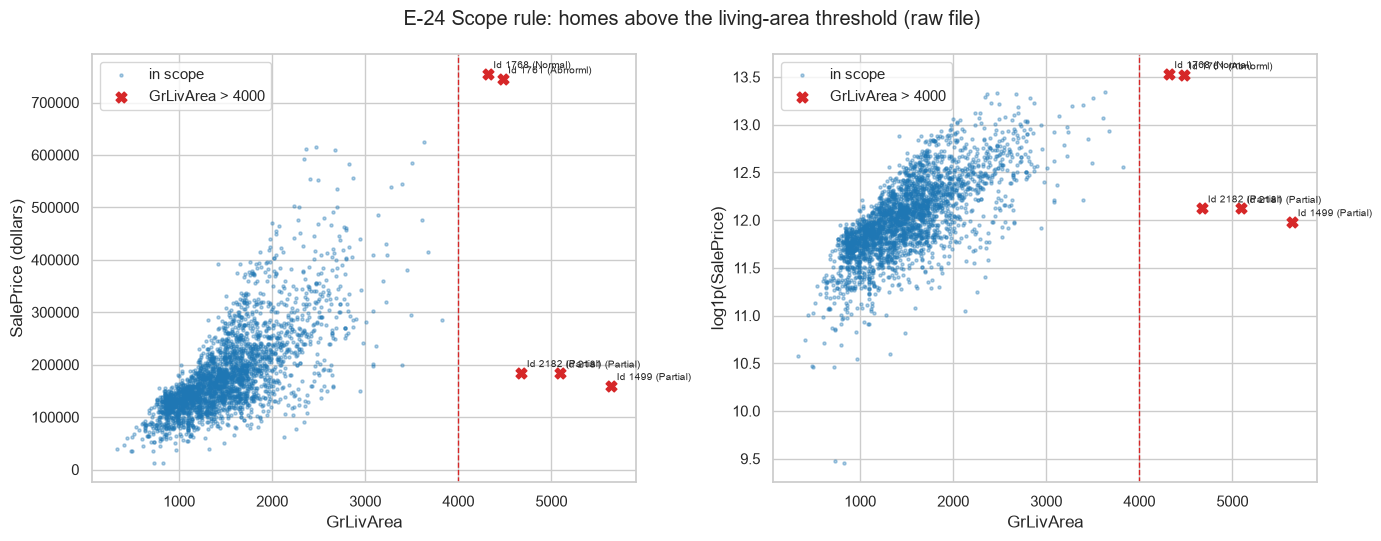

In [3]:
Image(filename=outputs.figures["E-24_scope_rule"])

## E-25 The out-of-scope homes and their residual from the in-scope size trend.

In [4]:
outputs.tables["E-25_out_of_scope_homes"]

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition,log_residual_vs_in_scope_trend,residual_in_sd,price_percentile_in_raw_file
0,1499,5642,160000,10,Partial,-2.500603,-8.762832,49.692833
1,1761,4476,745000,10,Abnorml,-0.269870,-0.945703,99.965870
2,1768,4316,755000,10,Normal,-0.161507,-0.565968,100.000000
3,2181,5095,183850,10,Partial,-2.036775,-7.137447,62.798635
4,2182,4676,184750,10,Partial,-1.783034,-6.248263,63.344710


## E-26 Slope of log price on `GrLivArea` with and without them.

In [5]:
outputs.tables["E-26_leverage_comparison"]

,fit,n,slope_per_1000_sqft,intercept,slope_change_pct_vs_all
0,all raw rows,2930,0.561064,11.179554,0.000000
1,in-scope rows only,2925,0.593934,11.132562,5.858585
